<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/experiment2/Experiment2_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Zelle 1 – Die zwei erweiterten CSVs laden:

In [6]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np

base = "/content/drive/MyDrive/ba_results/"
df_exp2 = pd.concat([pd.read_csv(base + "cotracker3_all_videos_v4.csv"),
                     pd.read_csv(base + "tapnext_all_videos_v4.csv")], ignore_index=True)
df_exp2["visibility_bias"] = df_exp2["false_visible_rate"] - df_exp2["false_occluded_rate"]  # >0 überkonfident, <0 konservativ
df_exp2.to_csv(base + "experiment2_combined_v4.csv", index=False)

blur_order = ["none", "medium", "strong"]
metrics2 = ["occlusion_accuracy", "outlier_magnitude", "outlier_ratio_vs_gt",
            "false_visible_rate", "false_occluded_rate", "visibility_bias"]
print(df_exp2.groupby(["model", "blur"])[metrics2].agg(["mean", "median"]).round(3))

import matplotlib.pyplot as plt

LABEL = {"CoTracker3": "CoTracker3", "TapNext": "TAPNext", "CoWTracker": "CoWTracker"}

def save(fig_name):
    for ext in ("png", "pdf"):
        plt.savefig(base + f"{fig_name}.{ext}", dpi=200, bbox_inches="tight")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                  occlusion_accuracy         outlier_magnitude         \
                                mean  median              mean median   
model      blur                                                         
CoTracker3 medium             80.375  87.428             6.605  6.147   
           none               88.131  89.689             7.296  6.427   
           strong             66.903  75.873             5.721  6.290   
TapNext    medium             77.256  83.896            12.744  7.099   
           none               91.340  93.194             9.179  7.883   
           strong             62.050  63.735            18.426  6.608   

                  outlier_ratio_vs_gt        false_visible_rate         \
                                 mean median               mean median   
model      blur                                                  

Zelle 2 – Vergleichsplots für alle drei Experiment-2-Metriken:

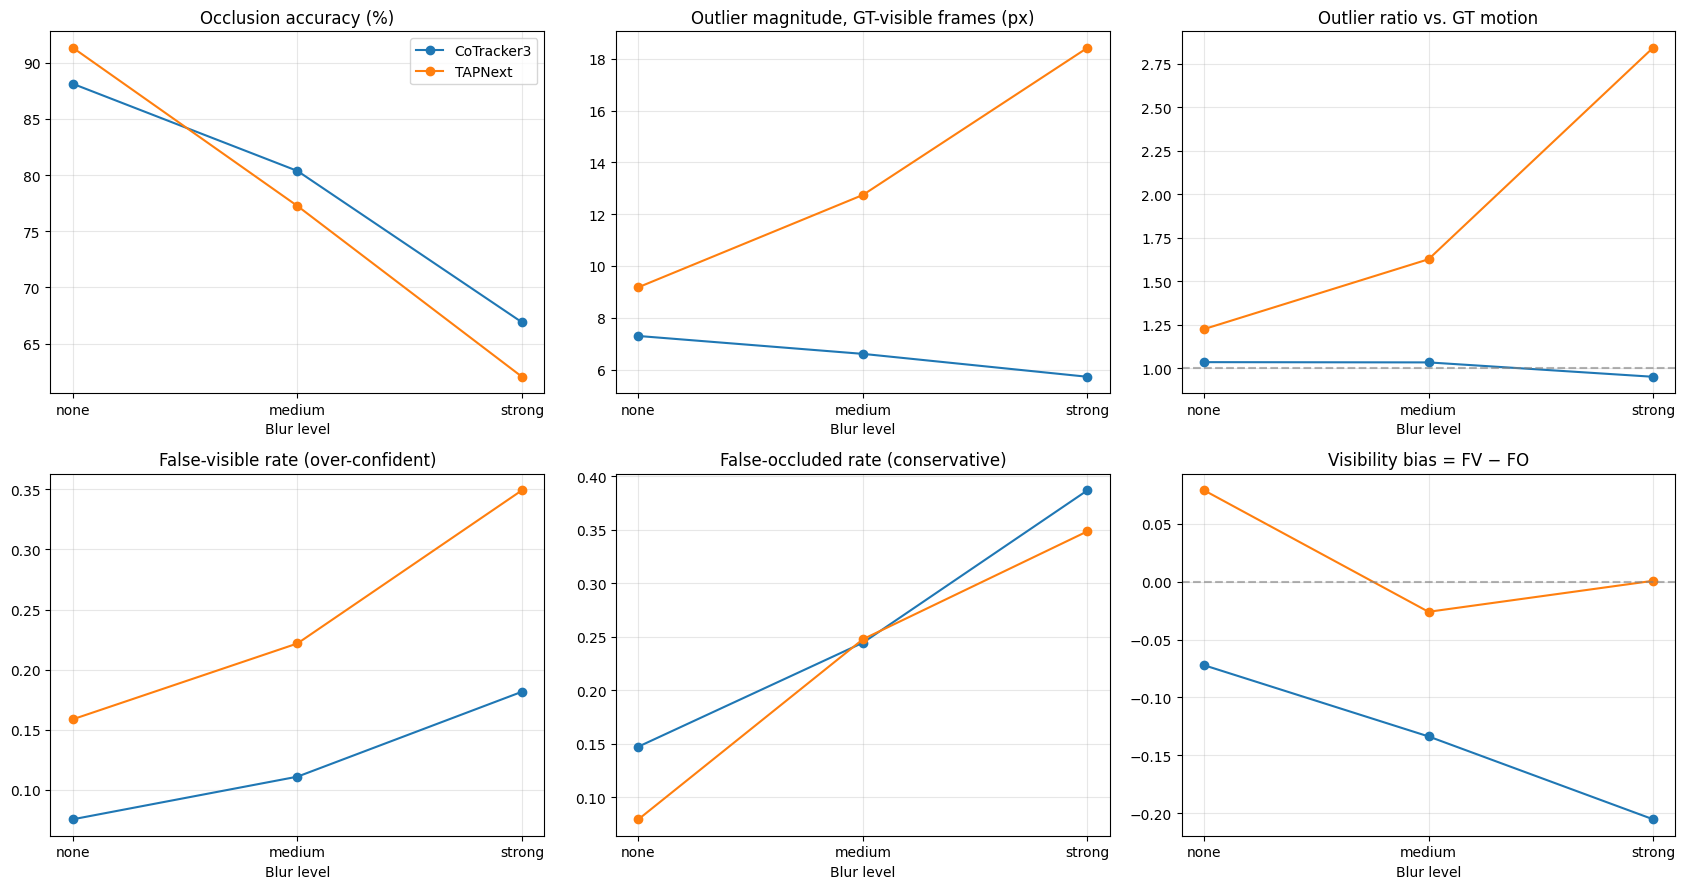

In [7]:
import matplotlib.pyplot as plt
titles = {"occlusion_accuracy": "Occlusion accuracy (%)",
          "outlier_magnitude": "Outlier magnitude, GT-visible frames (px)",
          "outlier_ratio_vs_gt": "Outlier ratio vs. GT motion",
          "false_visible_rate": "False-visible rate (over-confident)",
          "false_occluded_rate": "False-occluded rate (conservative)",
          "visibility_bias": "Visibility bias = FV − FO"}
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, metric in zip(axes.ravel(), metrics2):
    s = df_exp2.groupby(["model", "blur"])[metric].mean().reset_index()
    for m in ["CoTracker3", "TapNext"]:
        sub = s[s.model == m].set_index("blur").reindex(blur_order)
        ax.plot(blur_order, sub[metric], marker="o", label=LABEL[m])
    if metric == "outlier_ratio_vs_gt": ax.axhline(1.0, color="gray", ls="--", alpha=.6)
    if metric == "visibility_bias": ax.axhline(0.0, color="gray", ls="--", alpha=.6)
    ax.set_title(titles[metric]); ax.set_xlabel("Blur level"); ax.grid(alpha=.3)
axes[0, 0].legend(); plt.tight_layout(); save("exp2_comparison"); plt.show()

df_exp2.groupby(["model", "blur"])[metrics2].mean().round(3).to_csv(base + "experiment2_summary_table_v4.csv")

Zelle 3 - gepaarte Tests für Experiment 2

In [8]:
from scipy.stats import wilcoxon
for metric in ["outlier_magnitude", "outlier_ratio_vs_gt", "false_visible_rate", "false_occluded_rate", "visibility_bias"]:
    for level in blur_order:
        a = df_exp2[(df_exp2.model == "TapNext") & (df_exp2.blur == level)].set_index("video")[metric]
        b = df_exp2[(df_exp2.model == "CoTracker3") & (df_exp2.blur == level)].set_index("video")[metric]
        d = (a - b).dropna()
        print(f"{metric:20s} | {level:6s}: TapNext − CoTracker3 = {d.mean():7.3f} ± {1.96*d.std(ddof=1)/np.sqrt(len(d)):.3f} | p = {wilcoxon(d).pvalue:.4f}")
    print()

outlier_magnitude    | none  : TapNext − CoTracker3 =   1.883 ± 1.675 | p = 0.0000
outlier_magnitude    | medium: TapNext − CoTracker3 =   6.139 ± 4.216 | p = 0.0002
outlier_magnitude    | strong: TapNext − CoTracker3 =  12.705 ± 8.816 | p = 0.0310

outlier_ratio_vs_gt  | none  : TapNext − CoTracker3 =   0.190 ± 0.142 | p = 0.0002
outlier_ratio_vs_gt  | medium: TapNext − CoTracker3 =   0.593 ± 0.369 | p = 0.0005
outlier_ratio_vs_gt  | strong: TapNext − CoTracker3 =   1.893 ± 1.337 | p = 0.0197

false_visible_rate   | none  : TapNext − CoTracker3 =   0.083 ± 0.037 | p = 0.0003
false_visible_rate   | medium: TapNext − CoTracker3 =   0.111 ± 0.076 | p = 0.0074
false_visible_rate   | strong: TapNext − CoTracker3 =   0.168 ± 0.137 | p = 0.0345

false_occluded_rate  | none  : TapNext − CoTracker3 =  -0.068 ± 0.030 | p = 0.0000
false_occluded_rate  | medium: TapNext − CoTracker3 =   0.003 ± 0.058 | p = 0.4388
false_occluded_rate  | strong: TapNext − CoTracker3 =  -0.038 ± 0.098 | p = 0.4161



Für jeden der 20 Punkte maximale Sprungdistanz testen:

In [9]:
diffs_ct3 = np.linalg.norm(traj_ct3[:, 1:] - traj_ct3[:, :-1], axis=-1)  # (20, T-1)
diffs_tapnext = np.linalg.norm(traj_tapnext[:, 1:] - traj_tapnext[:, :-1], axis=-1)

max_jump_ct3 = diffs_ct3.max(axis=1)
max_jump_tapnext = diffs_tapnext.max(axis=1)

contrast = max_jump_tapnext - max_jump_ct3
best_point = np.argmax(contrast)

print("Bester Kontrast-Punkt:", best_point)
print("CoTracker3 max. Sprung:", max_jump_ct3[best_point])
print("TapNext max. Sprung:", max_jump_tapnext[best_point])

NameError: name 'traj_ct3' is not defined

Point Index = 8:

In [ ]:
point_idx = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(traj_ct3[point_idx, :, 0], label="x")
axes[0].plot(traj_ct3[point_idx, :, 1], label="y")
axes[0].set_title(f"CoTracker3 – Punkt {point_idx}")
axes[0].set_xlabel("Frame")
axes[0].legend()

axes[1].plot(traj_tapnext[point_idx, :, 0], label="x")
axes[1].plot(traj_tapnext[point_idx, :, 1], label="y")
axes[1].set_title(f"TapNext – Punkt {point_idx}")
axes[1].set_xlabel("Frame")
axes[1].legend()

plt.tight_layout()
plt.savefig(base + "qualitative_jitter_comparison.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
base = "/content/drive/MyDrive/ba_results/"
tn = pd.read_csv(base + "tapnext_all_videos_v4.csv")
ct = pd.read_csv(base + "cotracker3_all_videos_v4.csv")
m = tn[tn.blur == "strong"][["video", "outlier_ratio_vs_gt", "outlier_magnitude"]].merge(
    ct[ct.blur == "strong"][["video", "outlier_ratio_vs_gt", "outlier_magnitude"]],
    on="video", suffixes=("_tapnext", "_cotracker3"))
m["contrast"] = m["outlier_ratio_vs_gt_tapnext"] - m["outlier_ratio_vs_gt_cotracker3"]
print(m.sort_values("contrast", ascending=False).head(5).round(2))

DAVIS-Pickle

In [ ]:
!wget -q https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip && unzip -q -o tapvid_davis.zip
!ls -lh tapvid_davis

Qualitative Video22

In [ ]:
import pickle
with open("tapvid_davis/tapvid_davis.pkl", "rb") as f:
    davis_raw = pickle.load(f)
name = list(davis_raw.keys())[22]
occ = davis_raw[name]["occluded"]
ct = np.load(base + "cotracker3_traj_video22_strong.npy")
tn = np.load(base + "tapnext_traj_video22_strong.npy")
print(name, occ.shape, ct.shape, tn.shape)

p = 10
tq = int(np.argmax(~occ[p]))
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, k, lab in zip(axes, (0, 1), ("x (px)", "y (px)")):
    ax.plot(ct[p, :, k], lw=2, label="CoTracker3")
    ax.plot(tn[p, :, k], lw=2, label="TAPNext")
    for t in np.where(occ[p])[0]:
        ax.axvspan(t - .5, t + .5, color="0.85", lw=0)
    ax.axvline(tq, color="k", ls="--", alpha=.7)
    ax.set_ylabel(lab); ax.grid(alpha=.3)
axes[0].legend(); axes[1].set_xlabel("Frame")
axes[0].set_title(f"Video 22 ({name}), point {p}, strong blur – grey: GT occluded, dashed: query frame")
plt.tight_layout(); save("qualitative_video22"); plt.show()

Defining Blur functions

In [ ]:
def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    half = window_size // 2
    start, end = max(0, center_idx - half), min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0
    return ((window ** gamma).mean(axis=0) ** (1.0 / gamma) * 255).astype(np.uint8)

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

Rendering Blur Example

In [ ]:
frames = davis_raw[name]["video"]
print(frames.shape, frames.dtype)
idx = 24
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (lvl, w) in zip(axes, BLUR_LEVELS.items()):
    ax.imshow(apply_motion_blur(frames, idx, w))
    ax.set_title(f"{lvl} (window = {w})"); ax.axis("off")
plt.tight_layout(); save("blur_example_davis"); plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== EXP1 CHECK (soll 65.3 / 52.1 / 35.3) ===
blur
none      65.3
medium    52.1
strong    35.3

=== CoWTracker MEAN / MEDIAN ===
blur                              none  medium  strong
occlusion_accuracy      mean    92.113  89.899  85.606
                        median  93.952  92.498  88.935
outlier_magnitude       mean     7.673   7.922   8.378
                        median   6.533   7.039   8.948
outlier_ratio_vs_gt     mean     1.062   1.116   1.258
                        median   1.029   1.095   1.304
false_visible_rate      mean     0.285   0.348   0.436
                        median   0.235   0.258   0.386
false_occluded_rate     mean     0.024   0.033   0.054
                        median   0.008   0.014   0.031
visibility_bias         mean     0.260   0.315   0.381
                        median   0.202   0.245   0.345
trajectory_length_ratio mea

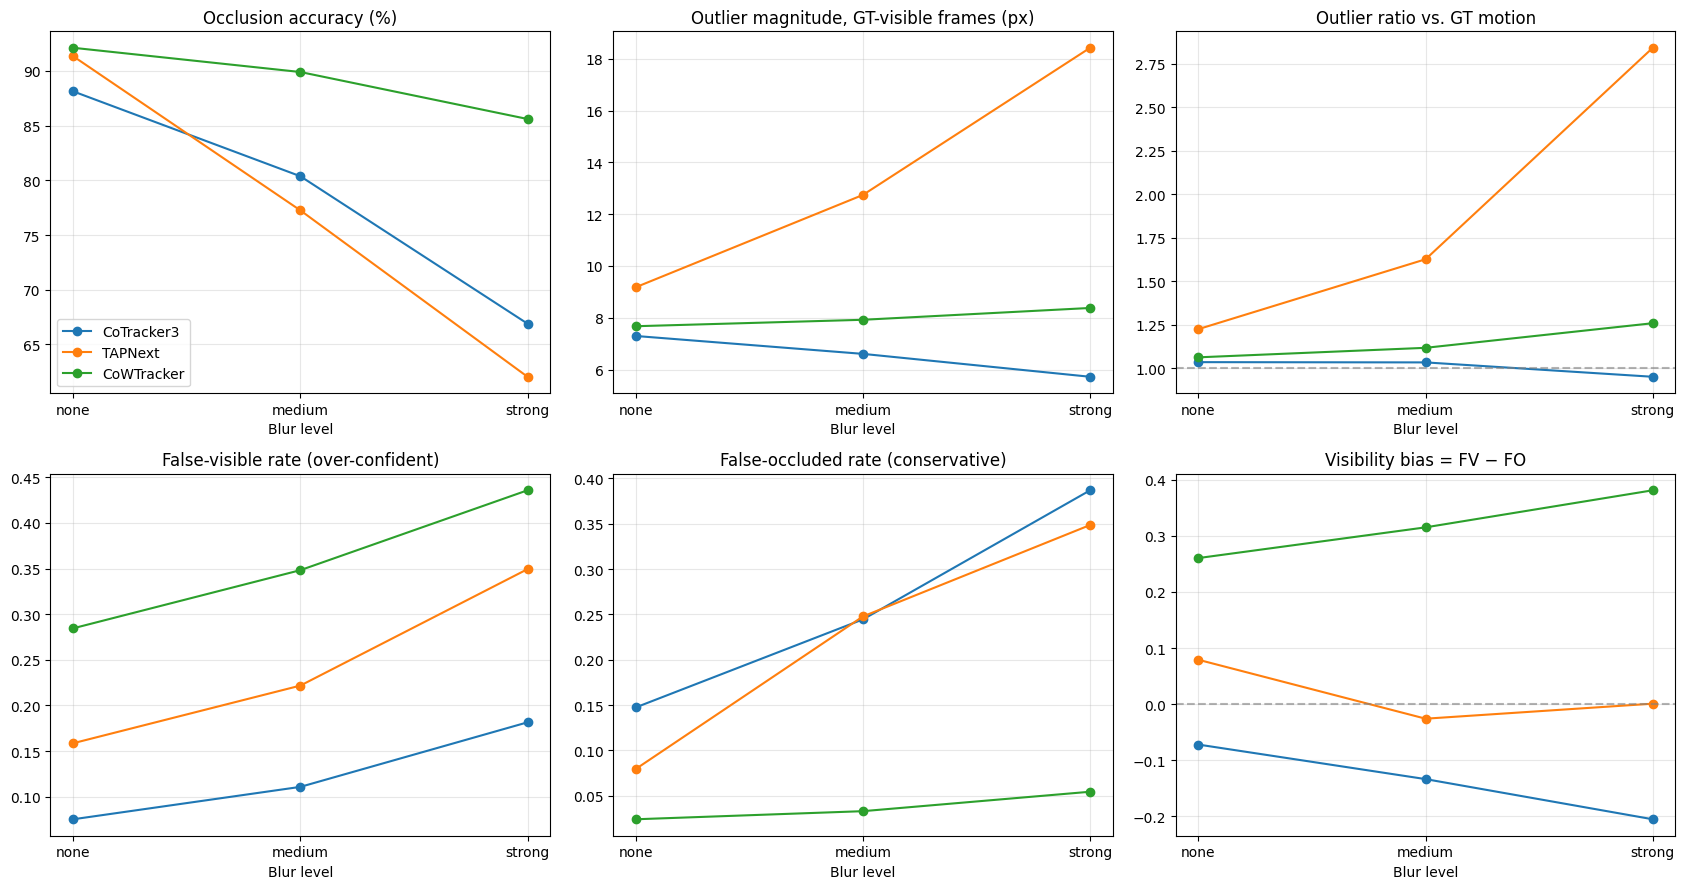


(Video-22-Plot uebersprungen: DAVIS-Pickle oder CoWTracker-Trajektorie nicht in dieser Sitzung gefunden - kein Problem, die alte Abbildung bleibt gueltig.)

=== BALANCED ACCURACY (%) ===
 blur        none  medium  strong
model                           
CoTracker3  88.9    82.2    71.6
CoWTracker  84.6    80.9    75.5
TapNext     88.1    76.5    65.1


In [10]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from google.colab import drive
drive.mount('/content/drive')
base = "/content/drive/MyDrive/ba_results/"

assert os.path.exists(base + "cowtracker_all_videos_v4.csv"), "cowtracker_all_videos_v4.csv fehlt - der CoWTracker-Lauf (Zelle A) ist noch nicht fertig."
cw = pd.read_csv(base + "cowtracker_all_videos_v4.csv")
assert len(cw) == 90, f"Nur {len(cw)} von 90 Zeilen - der Lauf ist noch nicht bei Video 29/29."

LABEL = {"CoTracker3": "CoTracker3", "TapNext": "TAPNext", "CoWTracker": "CoWTracker"}
blur_order = ["none", "medium", "strong"]
def save(n):
    for ext in ("png", "pdf"): plt.savefig(base + f"{n}.{ext}", dpi=200, bbox_inches="tight")

d3 = pd.concat([pd.read_csv(base + "cotracker3_all_videos_v4.csv"), pd.read_csv(base + "tapnext_all_videos_v4.csv"), cw], ignore_index=True)
d3["visibility_bias"] = d3["false_visible_rate"] - d3["false_occluded_rate"]
d3.to_csv(base + "experiment2_combined_3models.csv", index=False)
M = ["occlusion_accuracy", "outlier_magnitude", "outlier_ratio_vs_gt", "false_visible_rate", "false_occluded_rate", "visibility_bias"]
pd.set_option("display.width", 250)
cwm = d3[d3.model == "CoWTracker"]

print("=== EXP1 CHECK (soll 65.3 / 52.1 / 35.3) ===")
print(cwm.groupby("blur")["average_jaccard"].mean().round(1).reindex(blur_order).to_string())
print("\n=== CoWTracker MEAN / MEDIAN ===")
print(cwm.groupby("blur")[M + ["trajectory_length_ratio"]].agg(["mean", "median"]).round(3).reindex(blur_order).T.to_string())
print("\n=== CoWTracker max per-video outlier ratio ===")
print(cwm.groupby("blur")["outlier_ratio_vs_gt"].max().round(2).reindex(blur_order).to_string())
print("\n=== PAIRED TESTS ===")
for other in ["CoTracker3", "TapNext"]:
    for metric in M[1:]:
        for level in blur_order:
            x = d3[(d3.model == "CoWTracker") & (d3.blur == level)].set_index("video")[metric]
            y = d3[(d3.model == other) & (d3.blur == level)].set_index("video")[metric]
            d = (x - y).dropna()
            print(f"CoWTracker - {other:10s} | {metric:20s} | {level:6s}: {d.mean():8.3f} +- {1.96*d.std(ddof=1)/np.sqrt(len(d)):.3f} | p = {wilcoxon(d).pvalue:.4f}")
if os.path.exists(base + "cowtracker_all_videos_v3.csv"):
    v3 = pd.read_csv(base + "cowtracker_all_videos_v3.csv").sort_values(["video", "blur"])
    v4 = cw.sort_values(["video", "blur"])
    print("\n=== DETERMINISM: max |AJ v4 - v3| =", float(np.abs(v4.average_jaccard.values - v3.average_jaccard.values).max()))

titles = {"occlusion_accuracy": "Occlusion accuracy (%)", "outlier_magnitude": "Outlier magnitude, GT-visible frames (px)",
          "outlier_ratio_vs_gt": "Outlier ratio vs. GT motion", "false_visible_rate": "False-visible rate (over-confident)",
          "false_occluded_rate": "False-occluded rate (conservative)", "visibility_bias": "Visibility bias = FV − FO"}
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, metric in zip(axes.ravel(), M):
    s = d3.groupby(["model", "blur"])[metric].mean().reset_index()
    for m in ["CoTracker3", "TapNext", "CoWTracker"]:
        sub = s[s.model == m].set_index("blur").reindex(blur_order)
        ax.plot(blur_order, sub[metric], marker="o", label=LABEL[m])
    if metric == "outlier_ratio_vs_gt": ax.axhline(1.0, color="gray", ls="--", alpha=.6)
    if metric == "visibility_bias": ax.axhline(0.0, color="gray", ls="--", alpha=.6)
    ax.set_title(titles[metric]); ax.set_xlabel("Blur level"); ax.grid(alpha=.3)
axes[0, 0].legend(); plt.tight_layout(); save("exp2_comparison_3models"); plt.show()

pkl = next((q for q in ["tapvid_davis/tapvid_davis.pkl", "/content/tapvid_davis/tapvid_davis.pkl", "/content/cowtracker/tapvid_davis/tapvid_davis.pkl"] if os.path.exists(q)), None)
npy = base + "cowtracker_traj_video22_strong.npy"
if pkl and os.path.exists(npy):
    with open(pkl, "rb") as f: raw = pickle.load(f)
    name = list(raw.keys())[22]; occ = raw[name]["occluded"]; p = 10; tq = int(np.argmax(~occ[p]))
    trj = {"CoTracker3": np.load(base + "cotracker3_traj_video22_strong.npy"), "TAPNext": np.load(base + "tapnext_traj_video22_strong.npy"), "CoWTracker": np.load(npy)}
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for ax, k, lab in zip(axes, (0, 1), ("x (px)", "y (px)")):
        for n_, a in trj.items(): ax.plot(a[p, :, k], lw=2, label=n_)
        for t in np.where(occ[p])[0]: ax.axvspan(t - .5, t + .5, color="0.85", lw=0)
        ax.axvline(tq, color="k", ls="--", alpha=.7); ax.set_ylabel(lab); ax.grid(alpha=.3)
    axes[0].legend(); axes[1].set_xlabel("Frame")
    axes[0].set_title(f"Video 22 ({name}), point {p}, strong blur – grey: GT occluded, dashed: query frame")
    plt.tight_layout(); save("qualitative_video22_3models"); plt.show()
    j = np.linalg.norm(trj["CoWTracker"][p, 1:] - trj["CoWTracker"][p, :-1], axis=-1)
    print("\n=== CoWTracker point 10: max jump %.1f px (frame %d->%d), median %.2f px" % (j.max(), j.argmax(), j.argmax() + 1, np.median(j)))
else:
    print("\n(Video-22-Plot uebersprungen: DAVIS-Pickle oder CoWTracker-Trajektorie nicht in dieser Sitzung gefunden - kein Problem, die alte Abbildung bleibt gueltig.)")
    t = d3.groupby(["model", "blur"])[["false_visible_rate", "false_occluded_rate"]].mean()
print("\n=== BALANCED ACCURACY (%) ===\n", (100 * (1 - (t.false_visible_rate + t.false_occluded_rate) / 2)).round(1).unstack()[blur_order])